# Portfolio Project: Visualization in Python - Canada Immigration Analytics

---

# 03 — Advanced Statistical Visualization of Canadian Immigration

## Purpose

Notebook 02 established the main exploratory patterns using conventional line, bar, area, histogram, concentration, and scatter graphics.

This notebook moves one step further. Its purpose is to use **statistical visualization** to compare distributions, normalize trajectories, reveal high-dimensional patterns, and summarize relationships.

- Seaborn is used for higher-value statistical graphics;
- regression visualization is used as a **descriptive trend aid**, not as a predictive model;
- advanced graphics are selected to answer a distinct analytical question.

### Analytical questions

1. How do country-level immigration totals differ across continents?
2. How do developed and developing regions differ in the distribution of origin-country totals?
3. How did the continental composition of immigration change at selected points in time?
4. Which major origin countries experienced similar or different temporal patterns once scale is normalized?
5. How strongly are annual immigration levels associated with time, and how well does a simple linear visual trend summarize that relationship?
6. What does a compact correlation view reveal about broad co-movement among continental immigration series?


## 1. Load the cleaned dataset and prepare long-form data

The notebook uses the analysis-ready output from Notebook 01.  
A long-form representation is also created because Seaborn works naturally with tidy data structures in which each row represents one country-year observation.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

DATA_CANDIDATES = [
    Path("data") / "canada_immigration_clean.csv",
    Path("canada_immigration_clean.csv"),
]

DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "The cleaned dataset was not found. Run Notebook 01 first or place "
        "canada_immigration_clean.csv in the notebook directory or data/ subdirectory."
    )

df = pd.read_csv(DATA_PATH)
years = [str(year) for year in range(1980, 2014)]

required_columns = {
    "Country", "Continent", "Region", "Development_Group", "Total", *years
}
assert required_columns.issubset(df.columns)
assert df["Country"].is_unique

df_long = df.melt(
    id_vars=["Country", "Continent", "Region", "Development_Group", "Total"],
    value_vars=years,
    var_name="Year",
    value_name="Immigrants",
)
df_long["Year"] = df_long["Year"].astype(int)

print(f"Country-level dataset: {df.shape[0]} origins × {df.shape[1]} columns")
print(f"Long-form dataset: {df_long.shape[0]:,} country-year observations")
display(df_long.head())


Country-level dataset: 194 origins × 39 columns
Long-form dataset: 6,596 country-year observations


,Country,Continent,Region,Development_Group,Total,Year,Immigrants
0,Afghanistan,Asia,Southern Asia,Developing regions,58639,1980,16
1,Albania,Europe,Southern Europe,Developed regions,15699,1980,1
2,Algeria,Africa,Northern Africa,Developing regions,69439,1980,80
3,American Samoa,Oceania,Polynesia,Developing regions,6,1980,0
4,Andorra,Europe,Southern Europe,Developed regions,15,1980,0


## 2. How do country-level totals differ across continents?

Notebook 02 showed how continental immigration changed over time.  
Here the focus changes from aggregate volume to the **distribution of country-level cumulative totals within each continent**.

A boxplot is appropriate because it summarizes:

- the median;
- the interquartile range;
- dispersion;
- potential high-value outliers.

Because country totals are strongly right-skewed, the y-axis is displayed on a logarithmic scale. This preserves ordering while making differences among lower-volume origins visible.


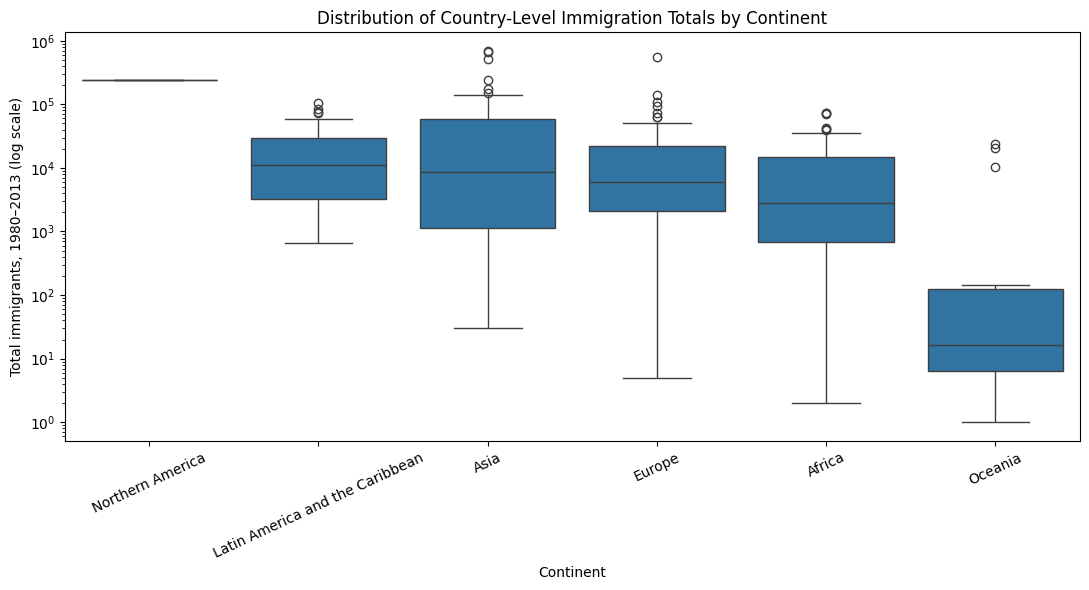

,count,median,mean,max
Continent,,,,
Northern America,1,241122.0,241122.0,241122
Latin America and the Caribbean,33,11193.0,23186.3,106431
Asia,49,8490.0,67710.1,691904
Europe,43,5963.0,32812.7,551500
Africa,54,2805.5,11462.0,72745
Oceania,14,16.5,3941.0,23829


In [2]:
continent_order = (
    df.groupby("Continent")["Total"]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(11, 6))

sns.boxplot(
    data=df,
    x="Continent",
    y="Total",
    order=continent_order,
    ax=ax,
)

ax.set_yscale("log")
ax.set_title("Distribution of Country-Level Immigration Totals by Continent")
ax.set_xlabel("Continent")
ax.set_ylabel("Total immigrants, 1980–2013 (log scale)")
ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

continent_stats = (
    df.groupby("Continent")["Total"]
    .agg(["count", "median", "mean", "max"])
    .sort_values("median", ascending=False)
    .round(1)
)

display(continent_stats)


### Interpretation

The distributions differ substantially across continents.

Asia has a much higher country-level mean than most other continents because several very large source countries sit in its upper tail. Europe also contains major high-volume origins, but its country-level distribution is less dominated by the same degree of extreme upper-end values.

The difference between mean and median within several continents confirms the strong right-skew already observed in Notebook 02. This is why a distributional graphic adds information that continent totals alone cannot provide.

Northern America contains only one retained origin country in this dataset, so its “distribution” should not be interpreted in the same way as continents with many countries.


## 3. How do developed and developing regions differ?

The workbook classifies origins into **Developed regions** and **Developing regions**.

Rather than comparing only average totals, a violin plot shows the full shape of each distribution. A logarithmic y-axis is again used because immigration totals span several orders of magnitude.

This is a descriptive comparison of distributions; no claim of causal difference is made.


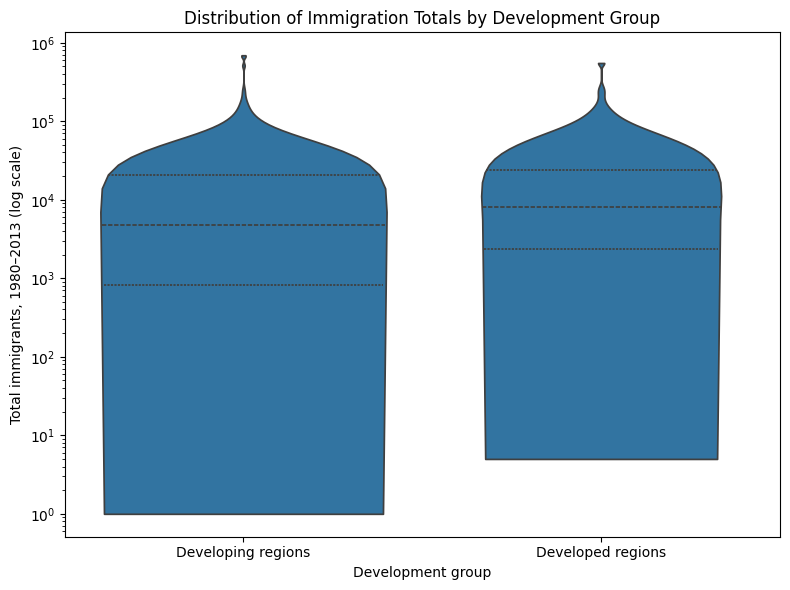

,count,median,mean,std,max
Development_Group,,,,,
Developed regions,47,8001.0,36467.9,88671.0,551500
Developing regions,147,4715.0,31939.7,93298.6,691904


In [3]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.violinplot(
    data=df,
    x="Development_Group",
    y="Total",
    inner="quartile",
    cut=0,
    ax=ax,
)

ax.set_yscale("log")
ax.set_title("Distribution of Immigration Totals by Development Group")
ax.set_xlabel("Development group")
ax.set_ylabel("Total immigrants, 1980–2013 (log scale)")

plt.tight_layout()
plt.show()

development_stats = (
    df.groupby("Development_Group")["Total"]
    .agg(["count", "median", "mean", "std", "max"])
    .round(1)
)

display(development_stats)


### Interpretation

The two groups overlap substantially, which is important: development classification does not cleanly separate high- and low-volume origin countries.

Developed regions have a higher median country-level total, but developing regions include several of the largest individual origin countries in the dataset. The violin shapes therefore reveal heterogeneity that would be hidden by a single mean comparison.

The unequal number of origins in the two groups should also be kept in mind when interpreting the distributions.


## 4. How did continental composition change at selected points in time?

Notebook 02 used a stacked area chart to show continuous change.  
Here, a **normalized heatmap** provides a complementary statistical view: each cell is the percentage of total immigration attributable to a continent in a selected year.

This representation makes structural shifts easier to compare because every column sums to 100%.


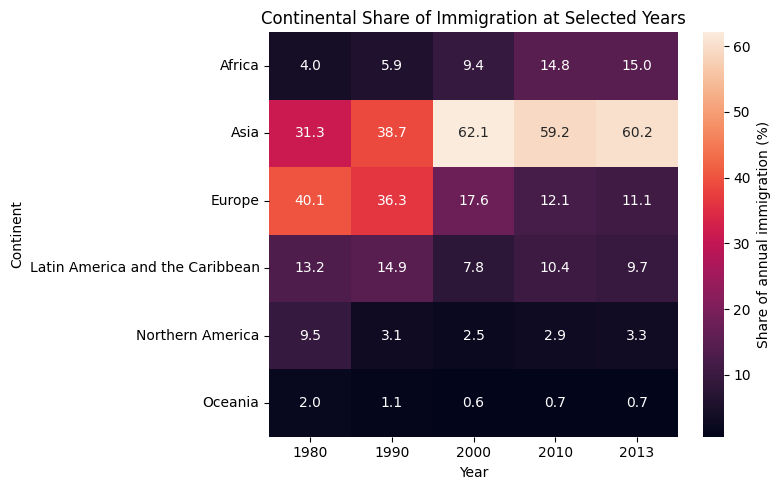

In [4]:
selected_years = ["1980", "1990", "2000", "2010", "2013"]

continent_selected = (
    df.groupby("Continent")[selected_years]
    .sum()
)

continent_share = (
    continent_selected
    .div(continent_selected.sum(axis=0), axis=1)
    * 100
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.heatmap(
    continent_share,
    annot=True,
    fmt=".1f",
    cbar_kws={"label": "Share of annual immigration (%)"},
    ax=ax,
)

ax.set_title("Continental Share of Immigration at Selected Years")
ax.set_xlabel("Year")
ax.set_ylabel("Continent")

plt.tight_layout()
plt.show()


### Interpretation

The heatmap makes the long-run compositional shift especially clear.

Europe accounted for roughly two-fifths of identified international immigration in 1980, while Asia accounted for about one-third. By 2000, Asia represented well over half of the annual total, and it remained near that level through 2013.

Africa's share also increased noticeably over the period. The visual therefore shows that the change in Canadian immigration was not only about total volume; the **geographic composition of source regions changed materially**.


## 5. Which major origin countries followed similar or different temporal patterns?

Raw annual counts are strongly influenced by scale: India and China, for example, can visually dominate smaller but still important origins.

To compare **shape rather than magnitude**, the top ten origins by cumulative immigration are standardized separately using z-scores:


z = (x - xbar)/s


A value above zero indicates a year above that country's own long-run average; a value below zero indicates a year below its own average.

The heatmap therefore emphasizes *when* each country was unusually high or low relative to its own history.


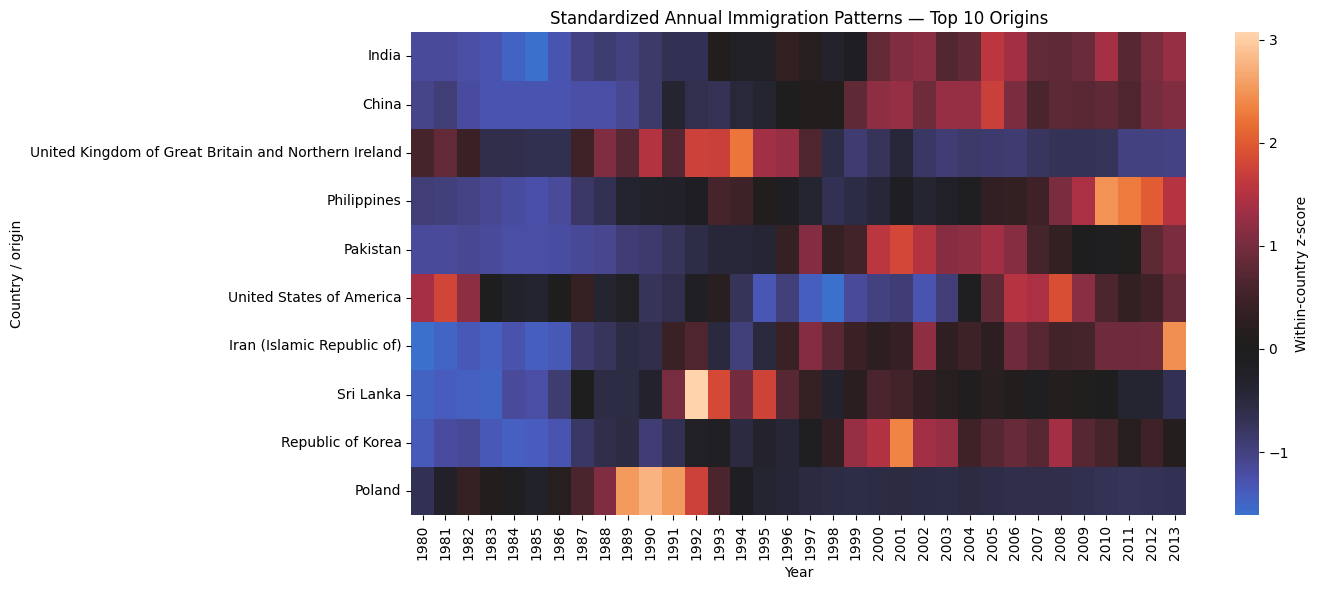

In [5]:
top10_countries = df.nlargest(10, "Total")["Country"].tolist()

top10_matrix = (
    df.set_index("Country")
    .loc[top10_countries, years]
    .astype(float)
)

top10_z = top10_matrix.sub(top10_matrix.mean(axis=1), axis=0)
top10_z = top10_z.div(top10_matrix.std(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    top10_z,
    center=0,
    cbar_kws={"label": "Within-country z-score"},
    ax=ax,
)

ax.set_title("Standardized Annual Immigration Patterns — Top 10 Origins")
ax.set_xlabel("Year")
ax.set_ylabel("Country / origin")

plt.tight_layout()
plt.show()


In [6]:
pattern_summary = []

for country in top10_countries:
    series = top10_matrix.loc[country]
    zseries = top10_z.loc[country]
    pattern_summary.append(
        {
            "Country": country,
            "Peak year": int(series.idxmax()),
            "Peak annual immigrants": int(series.max()),
            "Highest standardized year": int(zseries.idxmax()),
            "Maximum z-score": round(float(zseries.max()), 2),
        }
    )

display(pd.DataFrame(pattern_summary))


,Country,Peak year,Peak annual immigrants,Highest standardized year,Maximum z-score
0,India,2005,36210,2005,1.58
1,China,2005,42584,2005,1.71
2,United Kingdom of Great Britain and Northern I...,1994,39231,1994,2.24
3,Philippines,2010,38617,2010,2.48
4,Pakistan,2001,16708,2001,1.81
5,United States of America,2008,10190,2008,1.88
6,Iran (Islamic Republic of),2013,11291,2013,2.45
7,Sri Lanka,1992,13102,1992,3.07
8,Republic of Korea,2001,9619,2001,2.34
9,Poland,1990,17040,1990,2.77


### Interpretation

Normalization reveals patterns that are difficult to see in raw-value charts.

Some large origin countries reached their strongest relative periods in the early 1990s, others around the early or mid-2000s, and others near the end of the series. This confirms that “major source country” is not a single temporal profile.

The standardized heatmap is especially useful because it separates **timing** from **scale**. It should not be used to compare absolute immigrant counts; that purpose was handled by the raw-value charts in Notebook 02.


## 6. How well does a simple linear trend summarize total immigration over time?

The visualization below uses a fitted linear trend only as a **descriptive summary of association between year and annual immigration** using Seaborn regression plots. It is not treated as a forecasting model, causal model, or formal inferential analysis.

The observed annual values remain visible so that deviations from the fitted line are easy to assess.


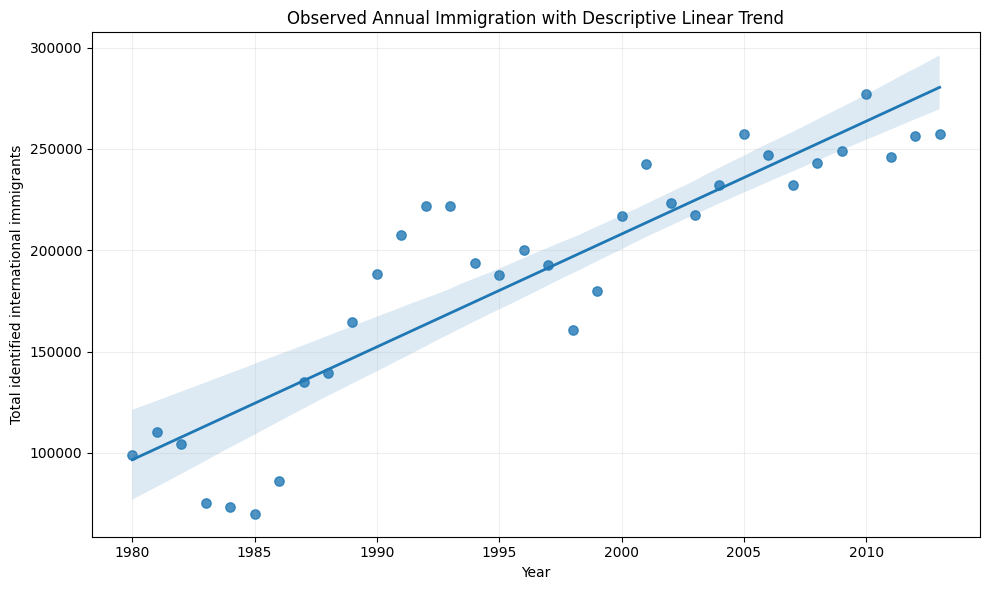

Pearson correlation between year and annual immigration: 0.897


In [7]:
annual_total = df[years].sum(axis=0)

annual_df = pd.DataFrame(
    {
        "Year": annual_total.index.astype(int),
        "Total_Immigrants": annual_total.values.astype(float),
    }
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.regplot(
    data=annual_df,
    x="Year",
    y="Total_Immigrants",
    ci=95,
    scatter_kws={"s": 45},
    line_kws={"linewidth": 2},
    ax=ax,
)

ax.set_title("Observed Annual Immigration with Descriptive Linear Trend")
ax.set_xlabel("Year")
ax.set_ylabel("Total identified international immigrants")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

correlation = annual_df["Year"].corr(annual_df["Total_Immigrants"])
print(f"Pearson correlation between year and annual immigration: {correlation:.3f}")


### Interpretation

The fitted line captures the broad long-run upward association between year and annual immigration, but the observed points visibly depart from a smooth linear path.

Those departures matter. They reinforce the conclusion from Notebook 02 that the immigration series contains phases, peaks, and reversals that a single linear trend cannot represent well.

The regression line is therefore useful as a compact **visual summary**, but not as a substitute for the full time-series pattern.


## 7. Do continental immigration series move together?

A correlation heatmap provides a compact view of broad co-movement among annual continental immigration totals.

For each continent, annual totals from 1980–2013 are calculated, then pairwise Pearson correlations are computed. A positive correlation means that two continental series tended to move in the same direction over time; a negative correlation indicates opposing movement.

This is descriptive association only. Correlation here does not imply that immigration from one continent causes immigration from another.


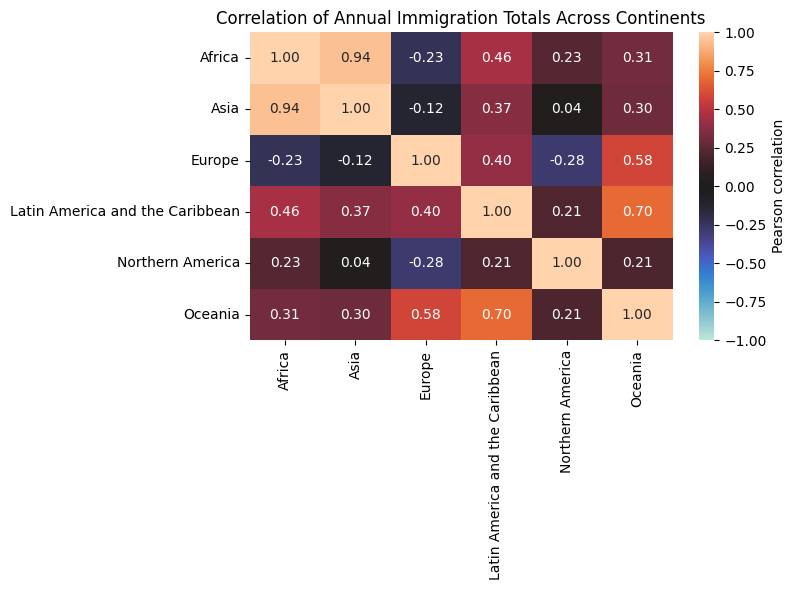

Continent,Africa,Asia,Europe,Latin America and the Caribbean,Northern America,Oceania
Continent,,,,,,
Africa,1.00,0.94,-0.23,0.46,0.23,0.31
Asia,0.94,1.00,-0.12,0.37,0.04,0.30
Europe,-0.23,-0.12,1.00,0.40,-0.28,0.58
Latin America and the Caribbean,0.46,0.37,0.40,1.00,0.21,0.70
Northern America,0.23,0.04,-0.28,0.21,1.00,0.21
Oceania,0.31,0.30,0.58,0.70,0.21,1.00


In [8]:
continent_annual = (
    df.groupby("Continent")[years]
    .sum()
    .T
    .astype(float)
)

continent_corr = continent_annual.corr()

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    continent_corr,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0,
    cbar_kws={"label": "Pearson correlation"},
    ax=ax,
)

ax.set_title("Correlation of Annual Immigration Totals Across Continents")
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

display(continent_corr.round(2))


### Interpretation

The correlation matrix summarizes whether continental immigration series tended to rise and fall together across the 34-year window.

Strong positive values suggest similar broad directional movement, whereas weaker or negative relationships indicate different long-run patterns. These associations should be interpreted cautiously because all series share the same national immigration environment and may also contain trends over time.

The heatmap is therefore best viewed as an exploratory summary of co-movement, not evidence of direct dependence.


## 8. Advanced statistical visualization findings

The statistical graphics add several insights beyond the exploratory plots in Notebook 02:

1. **Country-level immigration totals are highly heterogeneous within continents.** Means, medians, ranges, and upper tails differ substantially.
2. **Developed and developing regions overlap considerably.** Development classification alone does not determine the scale of an origin country's immigration contribution.
3. **The geographic composition changed structurally.** Asia's annual share increased sharply while Europe's declined.
4. **Major source countries had distinct timing patterns.** Standardization reveals when each origin was unusually high or low relative to its own long-run history.
5. **A linear trend captures only the broad upward association with time.** The annual series contains deviations that make a simple linear representation incomplete.
6. **Continental series exhibit differing degrees of co-movement.** Correlation is useful descriptively but should not be interpreted causally.

Together, these visualizations demonstrate how statistical graphics can reveal **distribution, composition, standardization, association, and temporal structure** without introducing unnecessary predictive modeling.


## 9. Visualization design rationale

| Analytical objective | Statistical visualization | Why it is used |
|---|---|---|
| Compare distributions across continents | Boxplot on log scale | Shows median, spread, skew, and outliers |
| Compare development groups | Violin plot on log scale | Shows distribution shape and quartiles |
| Compare normalized composition | Percentage heatmap | Makes structural shifts easy to compare |
| Compare temporal patterns independent of scale | Z-score heatmap | Separates timing from magnitude |
| Summarize time association | Seaborn regression plot | Shows broad linear tendency alongside observations |
| Summarize multivariate co-movement | Correlation heatmap | Compresses pairwise relationships into one matrix |

The notebook intentionally avoids adding models simply for complexity. Its role in the portfolio is to demonstrate **statistical visual reasoning** and appropriate selection of advanced Python visualization techniques.

**Next:** Notebook 04 will extend the analysis geographically using Folium and an interactive world map of immigration origins.
